In [3]:
pip install numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


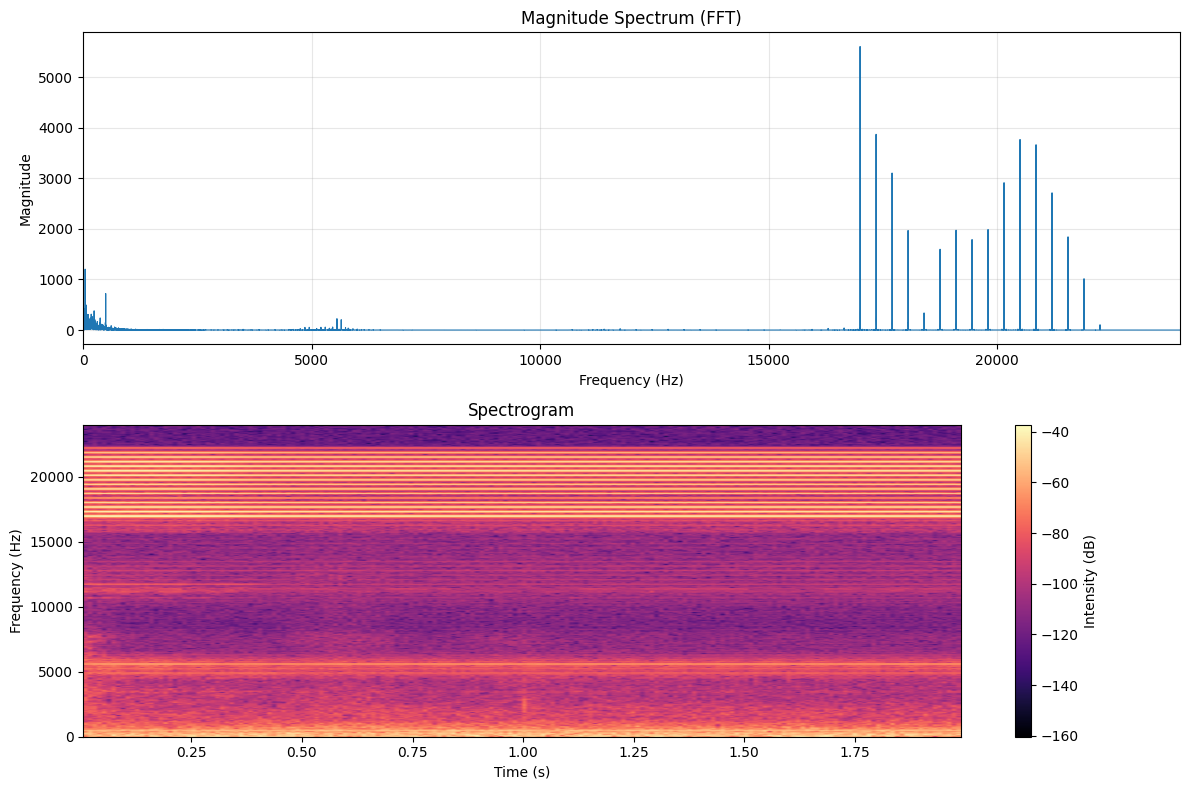

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# Adjust these if your PCM format is different
pcm_path = "data\\chunked\\sample_lowerA-Henry-20260403140615_chunk_0001.pcm"
sample_rate = 48000   # Hz
channels = 2          # set to 2 for stereo PCM
dtype = np.int16      # common PCM format

# Load raw PCM
raw = np.fromfile(pcm_path, dtype=dtype)

# Convert to mono float in [-1, 1]
if channels > 1:
    raw = raw[: len(raw) - (len(raw) % channels)]  # trim to full frames
    audio = raw.reshape(-1, channels).mean(axis=1).astype(np.float32)
else:
    audio = raw.astype(np.float32)

peak = np.max(np.abs(audio))
if peak > 0:
    audio = audio / peak

# Play audio
display(Audio(audio, rate=sample_rate))

# Spectral analysis plots
n = len(audio)
freqs = np.fft.rfftfreq(n, d=1 / sample_rate)
spectrum = np.abs(np.fft.rfft(audio))

plt.figure(figsize=(12, 8))

# Frequency spectrum (FFT magnitude)
plt.subplot(2, 1, 1)
plt.plot(freqs, spectrum, linewidth=0.8)
plt.title("Magnitude Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, sample_rate / 2)
plt.grid(alpha=0.3)

# Spectrogram
plt.subplot(2, 1, 2)
plt.specgram(audio, NFFT=1024, Fs=sample_rate, noverlap=512, cmap="magma")
plt.title("Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Intensity (dB)")

plt.tight_layout()
plt.show()

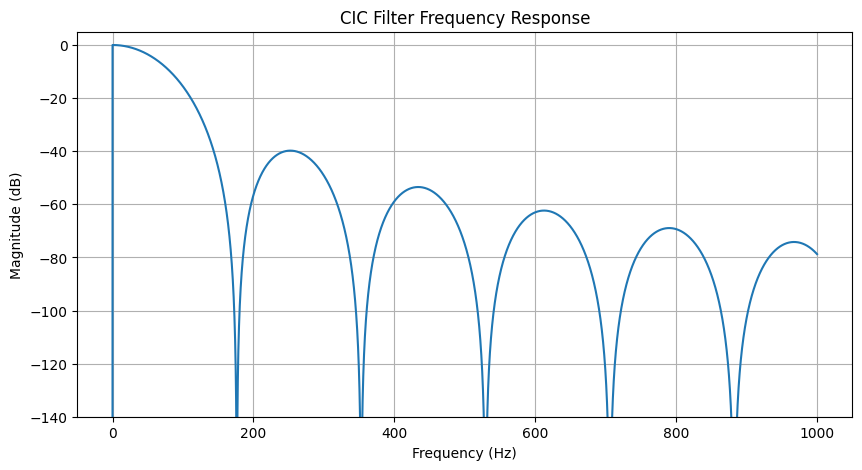

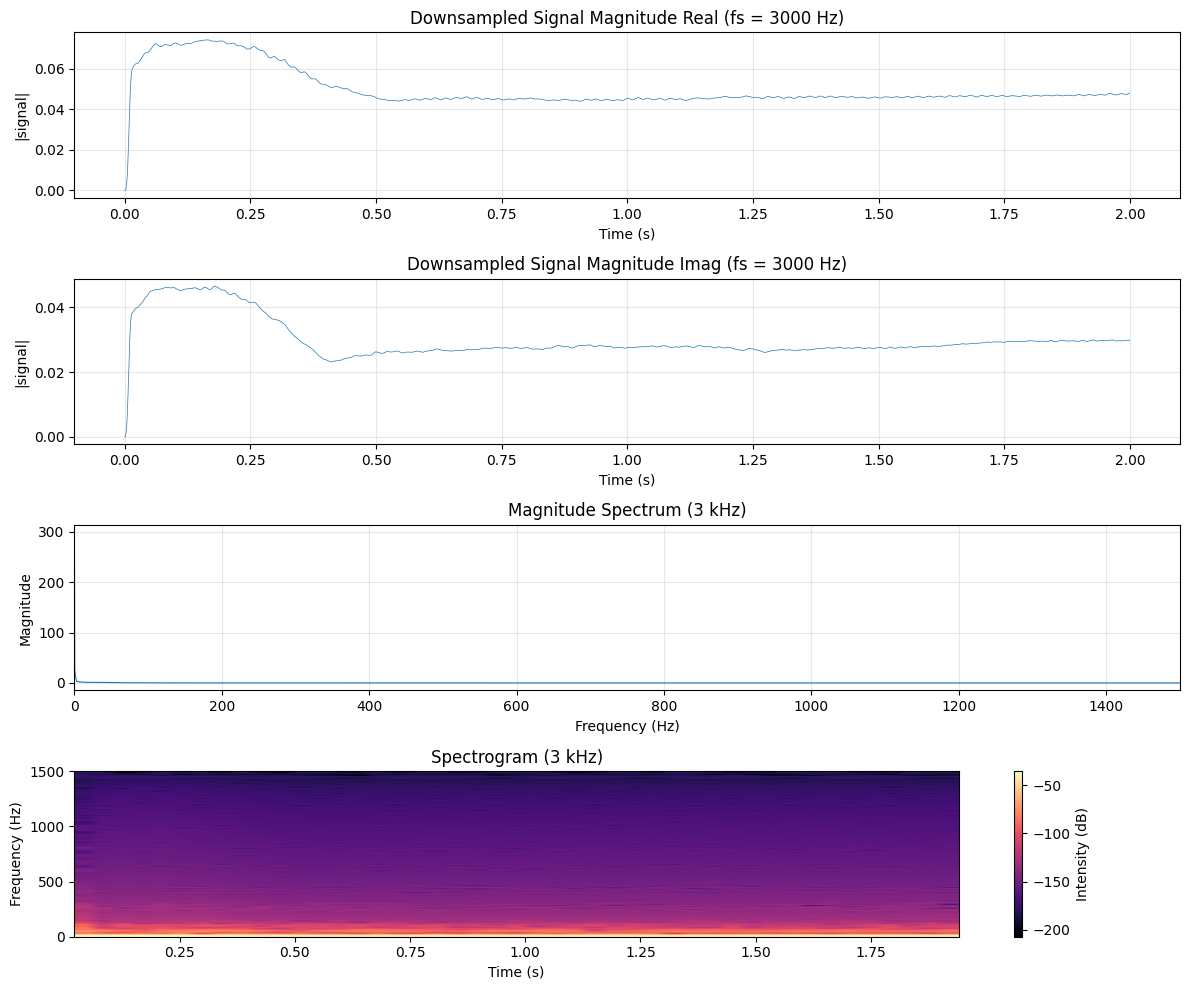

In [36]:
SPEED_OF_LIGHT = 299792458  # m/s

def lowpass_cic_filter(signal, decimation_factor, difference_delay=1, stages=3):
    signal = signal.astype(np.complex128)

    # Integrators
    for _ in range(stages):
        signal = np.cumsum(signal)

    # Decimate
    signal = signal[::decimation_factor]

    # Combs
    for _ in range(stages):
        delayed = np.concatenate((np.zeros(difference_delay, dtype=signal.dtype),
                                  signal[:-difference_delay]))
        signal = signal - delayed
        
    # normalize gain
    signal /= (decimation_factor * difference_delay) ** stages

    return signal

def down_convert(audio, sample_rate, carrier_freq):
    t = np.arange(len(audio)) / sample_rate
    iSignal = audio * np.cos(2 * np.pi * carrier_freq * t)
    qSignal = audio * -np.sin(2 * np.pi * carrier_freq * t)
    return iSignal + 1j * qSignal

# Example usage of down-conversion and CIC filter
carrier_freq = 17000  # Hz, example carrier frequency
downconverted = down_convert(audio, sample_rate, carrier_freq)

# We select the parameters so that the ﬁrstand second zeros of the ﬁlter appear at 175 Hz and 350 Hz. Thepass-band of the CIC ﬁlter is 0 ∼ 100 Hz, which corresponds to themovements with a speed lower than 0.95 m/s when the wavelengthis 1.9 cm. The second zero of the ﬁlter appears at 350 Hz so thatthe signals at (f ± 350) Hz will be attenuated by more than 120dB. Thus, to minimize the interferences from adjacent frequencies,we use a frequency interval of 350 Hz when the speaker transmitsmultiple frequencies simultaneously. To achieve better computa-tional efﬁciency, we do not use a frequency compensate FIR ﬁlterafter the CIC.
decimation_factor = 16
difference_delay = 17
stages = 3
filtered = lowpass_cic_filter(downconverted, decimation_factor, difference_delay, stages)

# CIC parameters
N = 3      # number of sections
R = 16     # decimation ratio
M = 17     # differential delay
fs = 48000 # sample rate (change as needed)

# Frequency axis
f = np.linspace(0, 1000, 20000)
w = 2 * np.pi * f / fs

# Avoid division by zero
eps = 1e-12
num = np.sin(w * R * M / 2)
den = np.sin(w / 2) + eps

# CIC magnitude response
H = (num / den) ** N
H = np.abs(H)

# Normalize
H = H / np.max(H)

# Convert to dB
H_db = 20 * np.log10(H + 1e-12)

# Plot
plt.figure(figsize=(10,5))
plt.plot(f, H_db)
plt.title("CIC Filter Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.ylim([-140, 5])
plt.grid(True)
plt.show()

# Plot down-converted and filtered signal spectrum
new_sample_rate = sample_rate / decimation_factor  # 3000 Hz
t_filtered = np.arange(len(filtered)) / new_sample_rate

freqs_filt = np.fft.rfftfreq(len(filtered), d=1 / new_sample_rate)
spectrum_filt = np.abs(np.fft.rfft(filtered))

plt.figure(figsize=(12, 10))

# Time-domain magnitude
plt.subplot(4, 1, 1)
plt.plot(t_filtered, np.abs(filtered.real), linewidth=0.5)
plt.title(f"Downsampled Signal Magnitude Real (fs = {new_sample_rate:.0f} Hz)")
plt.xlabel("Time (s)")
plt.ylabel("|signal|")
plt.grid(alpha=0.3)

plt.subplot(4, 1, 2)
plt.plot(t_filtered, np.abs(filtered.imag), linewidth=0.5)
plt.title(f"Downsampled Signal Magnitude Imag (fs = {new_sample_rate:.0f} Hz)")
plt.xlabel("Time (s)")
plt.ylabel("|signal|")
plt.grid(alpha=0.3)

# Frequency spectrum
plt.subplot(4, 1, 3)
plt.plot(freqs_filt, spectrum_filt, linewidth=0.8)
plt.title("Magnitude Spectrum (3 kHz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, new_sample_rate / 2)
plt.grid(alpha=0.3)

# Spectrogram
plt.subplot(4, 1, 4)
plt.specgram(np.real(filtered), NFFT=256, Fs=new_sample_rate, noverlap=128, cmap="magma")
plt.title("Spectrogram (3 kHz)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Intensity (dB)")

plt.tight_layout()
plt.show()


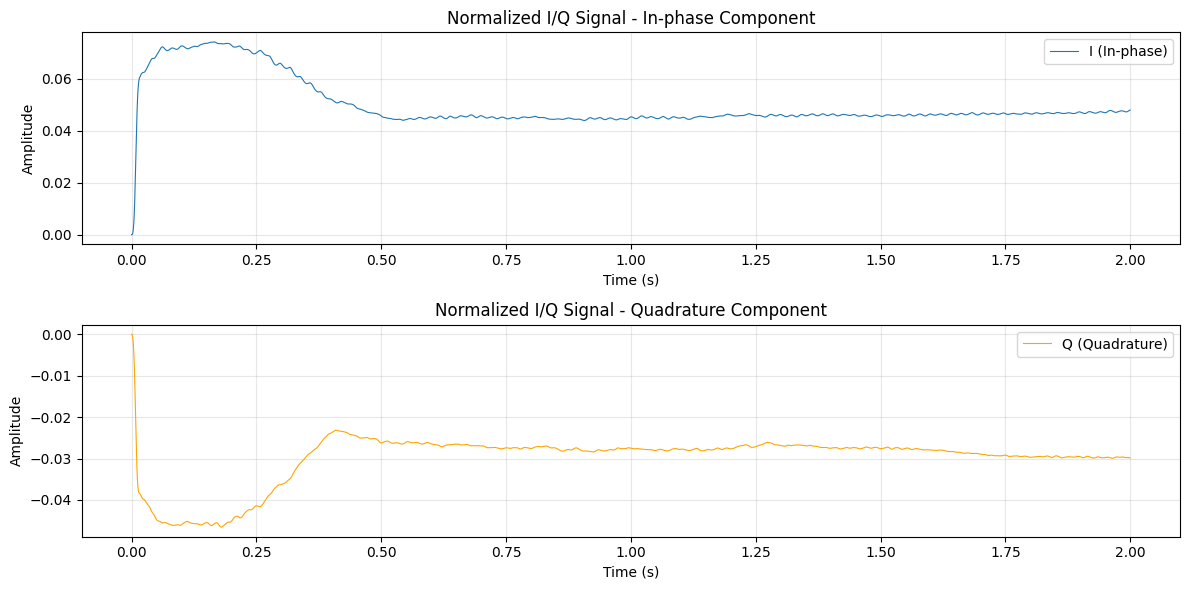

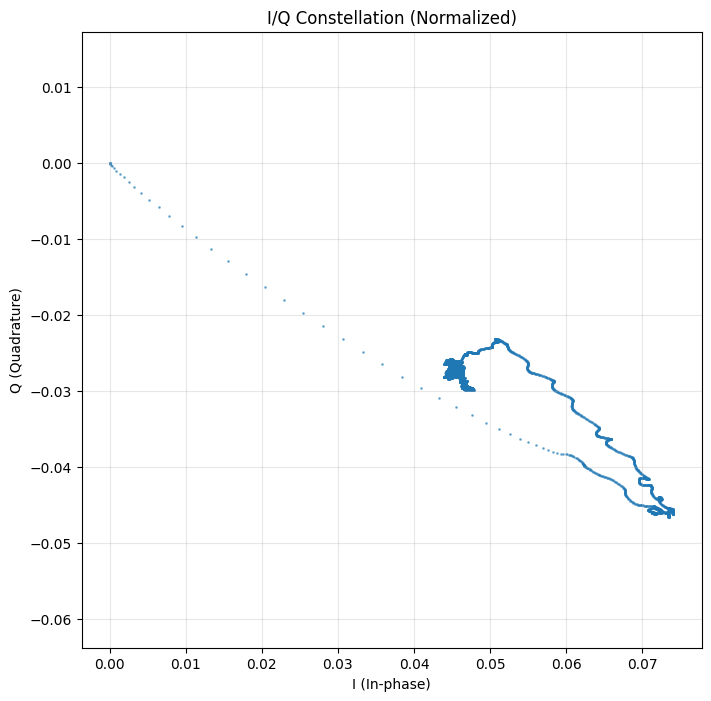

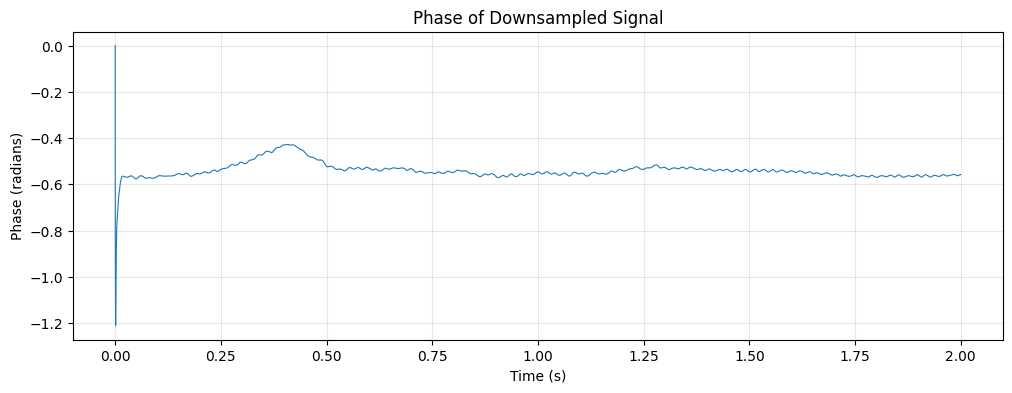

In [39]:
# Plot the normalized I/Q trace
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t_filtered, np.real(filtered), linewidth=0.8, label='I (In-phase)')
plt.title("Normalized I/Q Signal - In-phase Component")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_filtered, np.imag(filtered), linewidth=0.8, label='Q (Quadrature)', color='orange')
plt.title("Normalized I/Q Signal - Quadrature Component")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Also plot I/Q constellation
plt.figure(figsize=(8, 8))
plt.scatter(np.real(filtered), np.imag(filtered), s=1, alpha=0.5)
plt.title("I/Q Constellation (Normalized)")
plt.xlabel("I (In-phase)")
plt.ylabel("Q (Quadrature)")
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

phase = np.unwrap(np.angle(filtered))
plt.figure(figsize=(12, 4))
plt.plot(t_filtered, phase, linewidth=0.8)
plt.title("Phase of Downsampled Signal")
plt.xlabel("Time (s)")
plt.ylabel("Phase (radians)")
plt.grid(alpha=0.3)
plt.show()

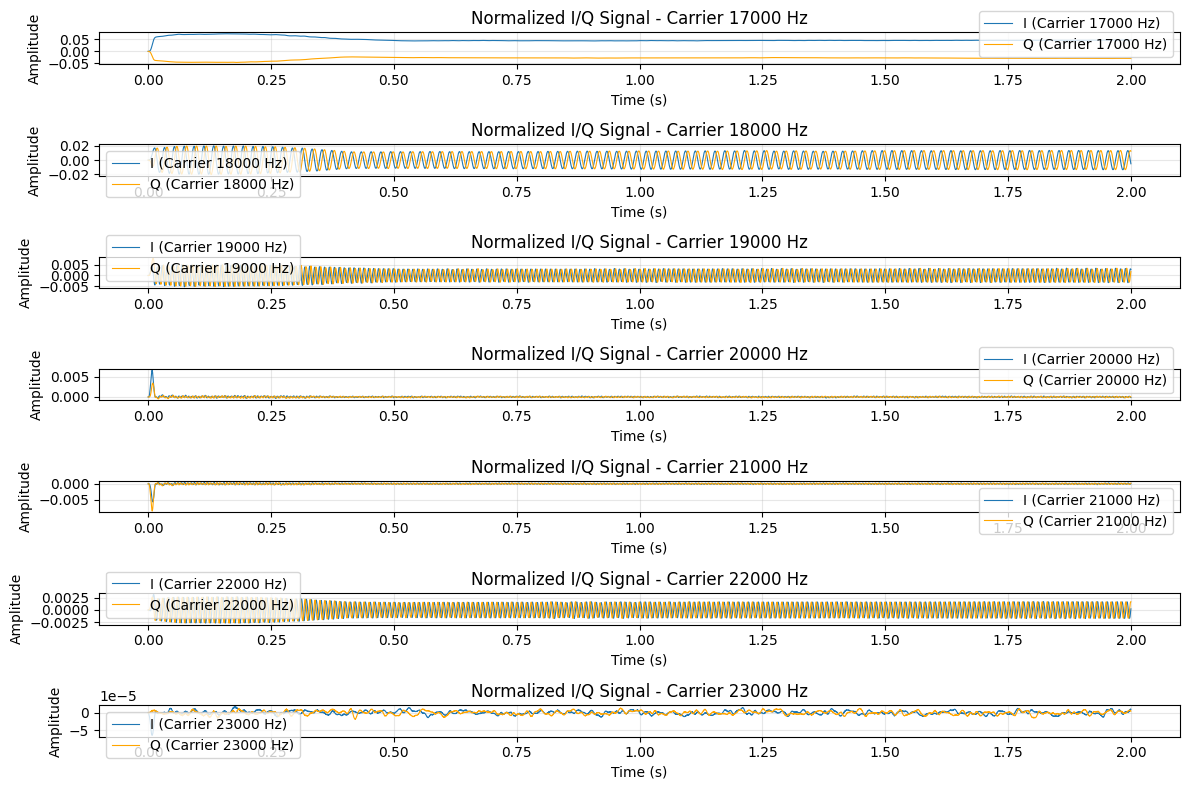

In [ ]:
carrier_freqs = [17000, 18000, 19000, 20000, 21000, 22000, 23000]

# graph i/q trace of each carrier frequency as 2d constellation plot
plt.figure(figsize=(12, 8))
for carrier_freq in carrier_freqs:
    downconverted = down_convert(audio, sample_rate, carrier_freq)
    filtered = lowpass_cic_filter(downconverted, decimation_factor, difference_delay, stages)
    t_filtered = np.arange(len(filtered)) / (sample_rate / decimation_factor)
    plt.scatter(np.real(filtered), np.imag(filtered), s=1, alpha=0.5, label=f'{carrier_freq} Hz')
plt.title("I/Q Constellation for Multiple Carrier Frequencies")
plt.xlabel("I (In-phase)")
plt.ylabel("Q (Quadrature)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()